# **DIDP model**

In [2]:
%%writefile JSP_single_dual_bound_DIDP_model_declaration.py
import sys
import os
import re
import math
import random
import numpy as np
import modified_didppy as m_dp

# ==========================================
# GLOBAL VARIABLES
# ==========================================
current_number_of_operations = 0
current_number_of_machines = 0
current_number_of_jobs = 0

# DIDP Sets
current_op_processing_time = []
current_op_deadline = []
current_op_predecessors = []
current_op_same_job = []
current_valid_machines = []
current_ops_on_machine = []
current_op_job_type = []
current_op_required_machine_type = []
current_map_mj_to_op = {}

# LP Sets
current_N = []
current_A = []
current_B = []
current_B_flat = []
current_p_mj = {}
current_J = []
current_M = []

def load_jsp_file(file_path):
    """
    Reads the content of a JSP instance file from disk.
    
    Args:
        file_path (str): The absolute or relative path to the .txt file.
        
    Returns:
        str: The raw string content of the file.
    """
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"The file was not found at: {file_path}")
    
    with open(file_path, 'r') as f:
        content = f.read()
    
    return content

def parse_jsp_instance(file_content):
    """
    Parses a JSP instance string (Taillard/Beasley format) and generates 
    ALL sets/parameters required for both LP Relaxation and DIDP models.
    
    Args:
        file_content (str): The raw text content of the instance file.
        
    Returns:
        dict: A dictionary containing all sets (J, M, N, A, B, etc.) and parameters.
    """
    # ---------------------------------------------------------
    # 1. Basic Parsing (Clean comments and header)
    # ---------------------------------------------------------
    lines = file_content.strip().split('\n')
    data_tokens = []
    
    for line in lines:
        # Remove comments (lines starting with # or [)
        if not line.strip() or line.strip().startswith('#') or line.strip().startswith('['):
            continue
        # Extract numbers
        tokens = re.findall(r'\d+', line)
        data_tokens.extend([int(t) for t in tokens])
        
    iterator = iter(data_tokens)
    
    try:
        num_jobs = next(iterator)
        num_machines = next(iterator)
    except StopIteration:
        raise ValueError("File is empty or invalid format")

    # ---------------------------------------------------------
    # 2. Raw Job Data Extraction
    # ---------------------------------------------------------
    # jobs_data format: [ [(machine, time), (machine, time)], ... ]
    jobs_data = []
    for _ in range(num_jobs):
        job_seq = []
        for _ in range(num_machines):
            m = next(iterator)
            p = next(iterator)
            job_seq.append((m, p))
        jobs_data.append(job_seq)

    num_operations = num_jobs * num_machines

    # ---------------------------------------------------------
    # 3. Build Structures for LP Relaxation (Lecture Note Style)
    # ---------------------------------------------------------
    # Sets based on (machine, job) tuples
    N = []              # Nodes: List of (m, j)
    A = []              # Solid Arcs: List of ((m_prev, j), (m_curr, j))
    B = []              # Broken Arcs (Graph): List of ((m, j), (m, k))
    B_flat = []         # Broken Arcs (LP Triplet): List of (m, j, k)
    p_mj = {}           # Processing time map: {(m, j): time}
    
    # Helpers for Broken Arcs
    machine_allocations = {m: [] for m in range(num_machines)}

    for j_idx, job_seq in enumerate(jobs_data):
        prev_node = None
        for (m, p) in job_seq:
            curr_node = (m, j_idx)
            
            # Populate N and p_mj
            N.append(curr_node)
            p_mj[curr_node] = float(p)
            
            # Populate Solid Arcs (A)
            if prev_node is not None:
                A.append((prev_node, curr_node))
            
            # Track for Broken Arcs
            machine_allocations[m].append(j_idx)
            prev_node = curr_node

    # Populate Broken Arcs - pairs on same machine
    for m in range(num_machines):
        assigned_jobs = machine_allocations[m]
        for i in range(len(assigned_jobs)):
            for k in range(i + 1, len(assigned_jobs)):
                job_1 = assigned_jobs[i]
                job_2 = assigned_jobs[k]
                
                # 1. Standard Disjunctive Graph Arc: ((m, j), (m, k))
                # Useful for graph plotting and disjunctive graph algos
                B.append(((m, job_1), (m, job_2)))
                
                # 2. Flat Triplet for LP variables: (m, j, k)
                # Useful for PuLP variables x_mjk
                B_flat.append((m, job_1, job_2))

    # ---------------------------------------------------------
    # 4. Build Structures for DIDP (Operation Index Style)
    # ---------------------------------------------------------
    # Flattened Operation ID: 0 to num_operations-1
    op_job_type = []
    op_required_machine_type = []
    op_processing_time = []
    op_predecessors = []
    op_deadline = []
    op_same_job = [[] for _ in range(num_operations)] # SJ_jo
    ops_on_machine = [[] for _ in range(num_machines)] # AO_k
    
    # Mapping to convert between (m,j) and op_id
    map_mj_to_op = {}
    
    # Define a default deadline (e.g., a large number covering the horizon)
    DEFAULT_DEADLINE = float('inf')
    
    op_counter = 0
    for j_idx, job_seq in enumerate(jobs_data):
        job_ops_indices = []
        
        for i, (m, p) in enumerate(job_seq):
            # Basic Attributes
            op_job_type.append(j_idx)
            op_required_machine_type.append(m)
            op_processing_time.append(float(p))
            op_deadline.append(DEFAULT_DEADLINE)
            
            # Map tracking
            map_mj_to_op[(m, j_idx)] = op_counter
            ops_on_machine[m].append(op_counter)
            job_ops_indices.append(op_counter)
            
            # Predecessors (P_jo)
            if i > 0:
                op_predecessors.append([op_counter - 1])
            else:
                op_predecessors.append([]) # First op has no pred
            
            op_counter += 1
            
            
        # Same Job Set (SJ_jo)
        for o_id in job_ops_indices:
            # All ops in this job EXCEPT self
            op_same_job[o_id] = [x for x in job_ops_indices if x != o_id]

    # Valid Machines (VM_jo) - Simple for static JSP
    valid_machines = [[op_required_machine_type[o]] for o in range(num_operations)]

    # ---------------------------------------------------------
    # 5. Return Master Dictionary
    # ---------------------------------------------------------
    return {
        "metadata": {
            "num_jobs": num_jobs,
            "num_machines": num_machines,
            "num_operations": num_operations
        },
        
        # --- Mathematical Programming Sets (LP Relax) ---
        "LP_sets": {
            "N": N,         # Nodes (m, j)
            "A": A,         # Solid Arcs
            "B": B,         # Broken Arcs (Nested Tuples)
            "B_flat": B_flat, # Broken Arcs (Flat Triplets: m, j, k)
            "p_mj": p_mj,   # Parameter p
            "J": list(range(num_jobs)),
            "M": list(range(num_machines))
        },
        
        # --- DIDP State Sets ---
        "DIDP_sets": {
            "op_job_type": op_job_type,                 # Job J per op
            "op_required_machine_type": op_required_machine_type, # Machine M per op
            "op_processing_time": op_processing_time,   # Time p per op
            "op_predecessors": op_predecessors,        # P_jo
            "op_deadline": op_deadline,               # Deadline D_jo
            "op_same_job": op_same_job,                 # SJ_jo
            "ops_on_machine": ops_on_machine,           # AO_k
            "valid_machines": valid_machines,           # VM_jo
            "map_mj_to_op": map_mj_to_op                # Helper: (m,j) -> op_id
        }
    }

def update_globals_for_jsp(file_path):
    """
    Updates global variables by reading/parsing the JSP file and 
    assigning values to the specific global variable names used by the DIDP model.
    """
    # 1. Declare ALL Globals used by DIDP Model & Dual Bounds
    global current_number_of_operations, current_number_of_machines, current_number_of_jobs
    global current_op_processing_time, current_op_deadline
    global current_op_predecessors, current_op_same_job
    global current_valid_machines, current_ops_on_machine
    global current_op_job_type, current_op_required_machine_type, current_map_mj_to_op
    
    # 2. Declare Globals used by LP Relaxation
    global current_N, current_A, current_B, current_B_flat, current_p_mj, current_J, current_M

    try:
        # A. Load and Parse
        file_content = load_jsp_file(file_path)
        data = parse_jsp_instance(file_content)
        
        # B. Assign Metadata
        current_number_of_operations = data['metadata']['num_operations']
        current_number_of_machines = data['metadata']['num_machines']
        current_number_of_jobs = data['metadata']['num_jobs']
        
        # C. Assign DIDP Sets
        didp = data['DIDP_sets']
        current_op_processing_time = didp['op_processing_time']
        current_op_deadline = didp['op_deadline']
        current_op_predecessors = didp['op_predecessors']
        current_op_same_job = didp['op_same_job']
        current_valid_machines = didp['valid_machines']
        current_ops_on_machine = didp['ops_on_machine']
        
        current_op_job_type = didp['op_job_type']
        current_op_required_machine_type = didp['op_required_machine_type']
        current_map_mj_to_op = didp['map_mj_to_op']

        # D. Assign LP Sets
        lp = data['LP_sets']
        current_N = lp['N']
        current_A = lp['A']
        current_B = lp['B']
        current_B_flat = lp['B_flat']
        current_p_mj = lp['p_mj']
        current_J = lp['J']
        current_M = lp['M']
        
        return True

    except Exception as e:
        print(f"   ❌ Error reading/parsing JSP data: {e}")
        # import traceback
        # traceback.print_exc()
        return False
    
def creation_of_didp_model_function():
    # -----------------------------
    # 1. Retrieve Global Variables
    # -----------------------------
    num_operations = current_number_of_operations
    num_machines = current_number_of_machines
    op_processing_time = current_op_processing_time
    op_deadline = current_op_deadline
    op_predecessors = current_op_predecessors
    op_same_job = current_op_same_job
    valid_machines = current_valid_machines
    ops_on_machine = current_ops_on_machine
    
    # NEW: Added requested variables
    op_job_type = current_op_job_type
    op_required_machine_type = current_op_required_machine_type

    # -----------------------------
    # 2. DIDP Model and Constants
    # -----------------------------
    model = m_dp.Model(maximize=False, float_cost=True)

    operation_obj = model.add_object_type(number=num_operations)
    machine_obj = model.add_object_type(number=num_machines)

    # Constant tables
    processing_time_table = model.add_float_table(op_processing_time)
    deadline_table = model.add_float_table(op_deadline)
    predecessor_table = model.add_set_table(op_predecessors, object_type=operation_obj)
    same_job_table = model.add_set_table(op_same_job, object_type=operation_obj)
    valid_machine_table = model.add_set_table(valid_machines, object_type=operation_obj)

    # -----------------------------
    # 3. State Variables
    # -----------------------------
    unscheduled_operations = model.add_set_var(object_type=operation_obj,
                                    target=list(range(num_operations)))
    finished_operations = model.add_set_var(object_type=operation_obj, target=[])
    machine_available_time = [
        model.add_float_resource_var(target=0, less_is_better=True, name=f"at_{mi}")
        for mi in range(num_machines)
    ]
    op_completion_time = [
        model.add_float_resource_var(target=0, less_is_better=True, name=f"c_{jo}")
        for jo in range(num_operations)
    ]

    # ------------------------------------------------------------
    # 4. Transitions
    # ------------------------------------------------------------
    # Schedule operation jo on the specified machine
    # ------------------------------------------------------------
    for o in range(num_operations):
        valid_machines_for_op = valid_machines[o]
        expr = m_dp.FloatExpr(0)
        #Finding the completion time of the predecessors to make sure 1 job cannot be operated on 2 machines at the same time
        if op_same_job[o]:
            job_exprs = [op_completion_time[k] for k in op_same_job[o]]
            expr = job_exprs[0]
            for e in job_exprs[1:]:
                expr = m_dp.max(expr, e)
        max_same_job_completion_time = expr
        for m in valid_machines_for_op:
            # Compute start & completion
            start_time = m_dp.max(machine_available_time[m], max_same_job_completion_time)
            completion_time = start_time + processing_time_table[o]
            cost_expr = m_dp.FloatExpr.state_cost()
            transition = m_dp.Transition(
                name=f"schedule_op{o}_on_m{m}",
                cost=cost_expr,
                preconditions=[
                    unscheduled_operations.contains(o),
                    predecessor_table[o].issubset(finished_operations),
                    completion_time <= deadline_table[o],
                ],
                effects=[
                    (unscheduled_operations, unscheduled_operations.remove(o)),
                    (finished_operations, finished_operations.add(o)),
                    (op_completion_time[o], completion_time),
                    (machine_available_time[m], completion_time),
                ],
            )
            model.add_transition(transition)

    # ------------------------------------------------------------
    # 5. Base case (OPTIMIZED)
    # ------------------------------------------------------------
    
    # Helper function to build a balanced max tree
    def build_balanced_max(expr_list):
        if not expr_list:
            return m_dp.FloatExpr(0)
        if len(expr_list) == 1:
            return expr_list[0]
        
        # Split in half
        mid = len(expr_list) // 2
        left_expr = build_balanced_max(expr_list[:mid])
        right_expr = build_balanced_max(expr_list[mid:])
        
        return m_dp.max(left_expr, right_expr)

    # Collect all completion time expressions into a list
    all_completion_times = [op_completion_time[o] for o in range(num_operations)]
    
    # Build the balanced expression
    makespan = build_balanced_max(all_completion_times)
    
    model.add_base_case([unscheduled_operations.is_empty()], cost=makespan)

    # ------------------------------------------------------------
    # Back up Base case
    # ------------------------------------------------------------
    """makespan = m_dp.FloatExpr(0)
    for o in range(num_operations):
        makespan = m_dp.max(makespan, op_completion_time[o])
    model.add_base_case([unscheduled_operations.is_empty()], cost=makespan)"""
    
    # ------------------------------------------------------------
    # 6. State Constraints
    # ------------------------------------------------------------
    # Enforce 0 <= completion time <= deadline for all operations
    for o in range(num_operations):
        # Upper bound: c(o) <= d(o)
        model.add_state_constr(op_completion_time[o] <= deadline_table[o])

        # ------------------------------------------------------------
    # 7. Dual Bound (optional)
    # ------------------------------------------------------------
    # Machine-based bound: for each machine m, available_time[m] + sum(remaining ptime on that machine)
    ops_on_machine_consts = [
        model.create_set_const(object_type=operation_obj, value=ops) for ops in ops_on_machine
    ]
    # remaining processing time on machine m = sum of ptime for operations on m that are still unscheduled
    remaining_time_on_machine = [
        processing_time_table[unscheduled_operations.intersection(ops_on_machine_consts[m])]
        for m in range(num_machines)
    ]
    machine_bound_exprs = [
        machine_available_time[m] + remaining_time_on_machine[m]
        for m in range(num_machines)
    ]

    # fold to a single dp.max expression
    dual_bound_expr = machine_bound_exprs[0]
    for b in machine_bound_exprs[1:]:
        dual_bound_expr = m_dp.max(dual_bound_expr, b)

    # Add dual bound to model
    model.add_dual_bound(dual_bound_expr)
    #"""

    # =========================================================
    # 8. Bundle Metadata
    # =========================================================
    metadata = {
        "unscheduled_operations": unscheduled_operations,
        "finished_operations": finished_operations,
        "machine_available_time": machine_available_time,
        "op_completion_time": op_completion_time,
        # Added the requested new variables to metadata
        "op_job_type": op_job_type,
        "op_required_machine_type": op_required_machine_type
    }
    
    didp_bundle = (model, metadata)
    return didp_bundle

Writing JSP_single_dual_bound_DIDP_model_declaration.py


# **Worker**

In [6]:
%%writefile worker_JSP_profiling.py
import sys
import os
import json
import time
import threading
import psutil
import modified_didppy as m_dp

# --- CONFIGURATION ---
MEMORY_LIMIT_MB = 12000 

# --- 1. SETUP PATHS ---
PROJECT_ROOT = r"C:\Users\ACER\Desktop\Code\0_Thesis_implementation\2_DIDP_custom_search_guidance_local\Thesis_modified_DIDP"
sys.path.append(os.getcwd()) 
if PROJECT_ROOT not in sys.path: sys.path.append(PROJECT_ROOT)

# --- 2. IMPORTS ---
try:
    import JSP_single_dual_bound_DIDP_model_declaration as domain
except ImportError as e:
    print(json.dumps({"status": "error", "message": f"Import Error: {e}"}))
    sys.exit(1)

# --- 3. MEMORY GUARD ---
def memory_guard():
    process = psutil.Process(os.getpid())
    limit_bytes = MEMORY_LIMIT_MB * 1024 * 1024
    while True:
        try:
            if process.memory_info().rss > limit_bytes:
                os._exit(1) # Hard exit to avoid swap death
            time.sleep(1)
        except: break

# --- 4. MAIN SOLVER LOGIC ---
if __name__ == "__main__":
    try:
        # Start Memory Guard
        threading.Thread(target=memory_guard, daemon=True).start()

        if len(sys.argv) < 5: 
            raise ValueError("Args mismatch. Usage: worker.py <instance> <data_dir> <time_limit> <node_limit>")
        
        instance_name = sys.argv[1]
        data_dir = sys.argv[2]
        time_limit = float(sys.argv[3])
        node_limit = int(sys.argv[4])

        file_path = os.path.join(data_dir, instance_name)
        if not os.path.exists(file_path): 
            # Check for common extensions
            if os.path.exists(file_path + ".txt"): file_path += ".txt"
            elif os.path.exists(file_path + ".jsp"): file_path += ".jsp"
        
        # 1. Load Instance
        if not domain.update_globals_for_jsp(file_path):
            raise ValueError(f"Failed to load: {file_path}")

        # 2. Setup Model (No Compilation needed, standard CABS)
        didp_bundle = domain.creation_of_didp_model_function() 
        model, metadata = didp_bundle
        
        # 3. Instantiate Solver (Standard CABS)
        # We use normal CABS because we are benchmarking the single dual bound defined in the model
        solver = m_dp.CABS(
            model,
            time_limit=time_limit,
            initial_beam_size=1,       
            max_beam_size=None,        
            quiet=False, # CRITICAL: Enable logs for parsing
        )
        
        start_time = time.time()
        
        # 4. Run Search (FAST C++ LOOP)
        # Passing node_limit enables profiling behavior
        solution = solver.search()
        
        duration = time.time() - start_time
        
        # 5. Output (History is in stdout logs)
        output = {
            "status": "success",
            "cost": solution.cost,
            "expanded": solution.expanded,
            "generated": solution.generated,
            "duration": duration,
            "is_optimal": solution.is_optimal,
            "history": [] # Manager parses this from stdout
        }
        print("\n" + json.dumps(output))

    except Exception as e:
        print("\n" + json.dumps({"status": "error", "message": str(e)}))
        sys.exit(1)

Overwriting worker_JSP_profiling.py


# **Execution**

In [4]:
import subprocess
import pandas as pd
import numpy as np
import os
import sys
import json
import matplotlib.pyplot as plt

# ==========================================
# CONFIGURATION
# ==========================================
NODE_EXPANSION_LIMIT = 100_000 
SOLVER_TIME_LIMIT = 900 

# Dataset Directory (Folder containing JSP instances)
DATA_DIR = r"C:\Users\ACER\Desktop\Code\0_Thesis_implementation\2_DIDP_custom_search_guidance_local\Thesis_modified_DIDP\5_JSP_dual_bounds_and_models\Datasets\JSPLIB_instances"

# CSV File containing list of instances to run
TARGET_LIST_CSV = "JSP_single_dual_bound_selected_results_1800s_lim.csv"

# Output for Profiling Logs
OUTPUT_FOLDER = "JSP_single_dual_bound_Profiling_Results"
os.makedirs(OUTPUT_FOLDER, exist_ok=True)

def run_profiling():
    print(f"🔹 Starting JSP Profiling (Max Nodes: {NODE_EXPANSION_LIMIT})...")
    
    # 1. Load Instance List from CSV
    if not os.path.exists(TARGET_LIST_CSV):
        print(f"❌ Target list CSV missing: {TARGET_LIST_CSV}")
        return
        
    try:
        df_targets = pd.read_csv(TARGET_LIST_CSV)
        # Assuming column is 'Instance' based on your provided file
        target_instances = df_targets['Instance'].tolist()
        print(f"   📋 Loaded {len(target_instances)} instances to profile from CSV.")
    except Exception as e:
        print(f"❌ Error reading target CSV: {e}")
        return

    # 2. Check Data Directory
    if not os.path.exists(DATA_DIR):
        print(f"❌ Data directory missing: {DATA_DIR}")
        return

    # 3. Process Only Listed Instances
    for i, instance_name in enumerate(target_instances):
        instance_name = str(instance_name).strip()
        safe_name = instance_name.replace(".txt", "").replace(".jsp", "")
        output_txt_path = os.path.join(OUTPUT_FOLDER, f"solver_log_{safe_name}.txt")
        
        # Resume Check
        if os.path.exists(output_txt_path) and os.path.getsize(output_txt_path) > 100:
            print(f"[{i+1}/{len(target_instances)}] Skipping {instance_name} (Log exists).")
            continue 

        # Check if file exists in DATA_DIR (handle optional .txt extension in filename)
        full_path = os.path.join(DATA_DIR, instance_name)
        if not os.path.exists(full_path):
             if os.path.exists(full_path + ".txt"):
                 instance_name += ".txt"
             elif os.path.exists(full_path + ".jsp"):
                 instance_name += ".jsp"
             else:
                 print(f"⚠️  Instance file not found in DATA_DIR: {instance_name}")
                 continue

        print(f"\n[{i+1}/{len(target_instances)}] Profiling {instance_name}...")
        
        # Run Worker
        cmd = [
            sys.executable, "-u", "worker_JSP_profiling.py",
            instance_name, DATA_DIR, str(SOLVER_TIME_LIMIT), str(NODE_EXPANSION_LIMIT)
        ]
        
        try:
            result = subprocess.run(cmd, capture_output=True, text=True)
            
            # --- SAVE TXT LOG ---
            with open(output_txt_path, "w", encoding="utf-8") as f:
                f.write(f"Instance: {instance_name}\n")
                f.write("="*40 + "\n\n")
                f.write(result.stdout)
                if result.stderr:
                    f.write("\n\n=== STDERR ===\n")
                    f.write(result.stderr)
            
            if result.returncode != 0:
                print(f"   ⚠️ Worker Failed. Log saved.")
            else:
                print(f"   ✅ Finished.")
            
        except Exception as e:
            print(f"   ❌ Error executing worker: {e}")

if __name__ == "__main__":
    run_profiling()

🔹 Starting JSP Profiling (Max Nodes: 100000)...
   📋 Loaded 10 instances to profile from CSV.

[1/10] Profiling abz5.txt...
   ✅ Finished.

[2/10] Profiling ft06.txt...
   ✅ Finished.

[3/10] Profiling ft10.txt...
   ✅ Finished.

[4/10] Profiling la07.txt...
   ✅ Finished.

[5/10] Profiling la21.txt...
   ✅ Finished.

[6/10] Profiling la26.txt...
   ✅ Finished.

[7/10] Profiling ta01.txt...
   ✅ Finished.

[8/10] Profiling ft20.txt...
   ✅ Finished.

[9/10] Profiling ta20.txt...
   ✅ Finished.

[10/10] Profiling ta41.txt...
   ✅ Finished.


# Data collection

🔹 Processing JSP Logs (Plot Limit: 100000)...
   Found 10 log files.

📊 Aggregating Results...
   ✅ Saved aggregated data to JSP_single_dual_bound_Profiles_Parsed\JSP_single_dual_bound_Average_gaps_vs_Expansion_limit.csv
   ✅ Saved plot to JSP_single_dual_bound_Profiles_Parsed


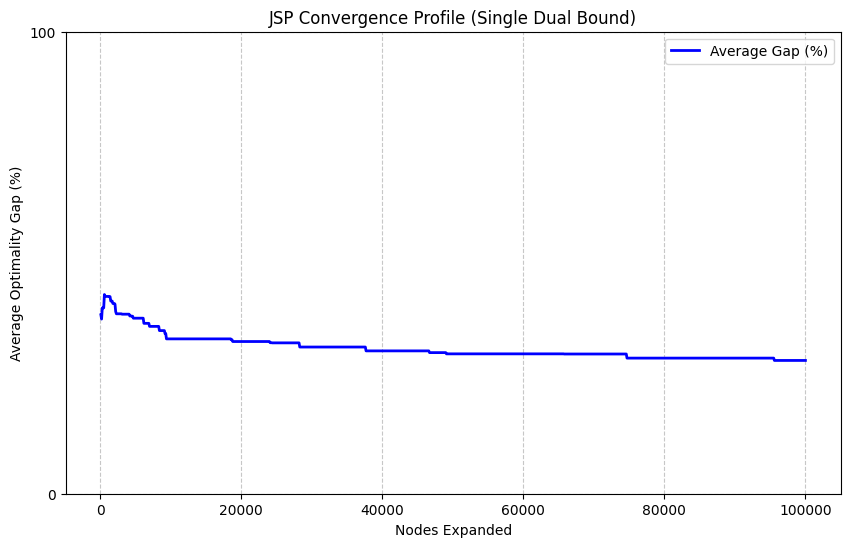

In [7]:
import pandas as pd
import numpy as np
import os
import re
import glob
import math
import matplotlib.pyplot as plt

# ==========================================
# CONFIGURATION
# ==========================================
LOG_DIR = "JSP_single_dual_bound_Profiling_Results"
OUTPUT_PROFILE_DIR = "JSP_single_dual_bound_Profiles_Parsed"
os.makedirs(OUTPUT_PROFILE_DIR, exist_ok=True)

REF_RESULTS_CSV = "JSP_single_dual_bound_selected_results_1800s_lim.csv" 
NODE_EXPANSION_LIMIT = 100_000 
SAMPLE_STEP = 100 

# ==========================================
# HELPER FUNCTIONS
# ==========================================
def parse_solver_log(file_path):
    """
    Reads log line-by-line. Cleans history to ensure best cost is used.
    """
    raw_history = []
    current_best_cost = float('inf')
    
    try:
        with open(file_path, 'r', encoding='utf-8') as f:
            for line in f:
                line = line.strip()
                
                # 1. New Primal Bound
                match_primal = re.search(r"New primal bound:\s*([0-9\.\+\-eE]+),\s*expanded:\s*(\d+)", line)
                if match_primal:
                    cost = float(match_primal.group(1))
                    expanded = int(match_primal.group(2))
                    current_best_cost = cost
                    raw_history.append((expanded, cost))
                    if expanded > NODE_EXPANSION_LIMIT: break
                    continue

                # 2. Beam Search Progress
                match_beam = re.search(r"Searched with beam size:.*expanded:\s*(\d+)", line)
                if match_beam:
                    expanded = int(match_beam.group(1))
                    raw_history.append((expanded, current_best_cost))
                    if expanded > NODE_EXPANSION_LIMIT: break
                        
    except Exception as e:
        print(f"Error reading {file_path}: {e}")
    
    # Clean History: Handle duplicates by keeping BEST cost
    raw_history.sort(key=lambda x: x[0])
    cleaned_history = []
    for expanded, cost in raw_history:
        if not cleaned_history:
            cleaned_history.append((expanded, cost))
        else:
            last_expanded, last_cost = cleaned_history[-1]
            if expanded == last_expanded:
                cleaned_history[-1] = (expanded, min(cost, last_cost))
            else:
                cleaned_history.append((expanded, cost))
                
    return cleaned_history

def calculate_dense_gaps(history, optimal_cost, limit):
    """
    Generates a dense gap array.
    - Leaves gap as NaN if no solution found yet.
    - Cuts off data (leaves as NaN) if solver stopped early (less nodes than limit).
    """
    max_steps = limit // SAMPLE_STEP
    dense_gaps = np.full(max_steps, np.nan)

    if not history: return dense_gaps

    current_cost = float('inf')
    hist_idx = 0
    
    # Get the furthest point the solver actually reached in this run
    max_nodes_reached = history[-1][0]
    
    for i in range(max_steps):
        current_node_count = (i + 1) * SAMPLE_STEP
        
        # --- CUTOFF LOGIC ---
        # If the current sampling point is beyond where the solver stopped,
        # we break the loop. This leaves the remaining values as NaN.
        if current_node_count > max_nodes_reached:
            break
        
        # Advance through history
        while hist_idx < len(history) and history[hist_idx][0] <= current_node_count:
            val = history[hist_idx][1]
            if val < current_cost:
                current_cost = val
            hist_idx += 1
            
        if current_cost == float('inf'):
            dense_gaps[i] = np.nan # Keep as NaN
        else:
            denom = optimal_cost if optimal_cost > 0 else 1.0
            gap = (current_cost - optimal_cost) / denom * 100.0
            if gap < 0: gap = 0.0 
            dense_gaps[i] = gap
        
    return dense_gaps

def process_results():
    print(f"🔹 Processing JSP Logs (Plot Limit: {NODE_EXPANSION_LIMIT})...")
    
    if not os.path.exists(REF_RESULTS_CSV):
        print(f"❌ Reference CSV missing: {REF_RESULTS_CSV}")
        return
    
    df_ref = pd.read_csv(REF_RESULTS_CSV)
    
    # Map: "instance" -> optimal_cost
    bks_map = {
        str(row['Instance']).replace(".txt", "").strip(): float(row['Best Known Cost']) 
        for _, row in df_ref.iterrows()
    }

    log_files = glob.glob(os.path.join(LOG_DIR, "solver_log_*.txt"))
    print(f"   Found {len(log_files)} log files.")
    
    all_dense_gaps = []

    for log_path in log_files:
        filename = os.path.basename(log_path)
        name_clean = filename.replace("solver_log_", "").replace(".txt", "").strip()
        
        if name_clean not in bks_map:
            found_key = None
            for k in bks_map:
                if name_clean == k: found_key = k; break
            if not found_key: continue
            name_clean = found_key

        opt_cost = bks_map[name_clean]
        history = parse_solver_log(log_path)
        
        if history:
            dense_gaps = calculate_dense_gaps(history, opt_cost, NODE_EXPANSION_LIMIT)
            all_dense_gaps.append(dense_gaps)
            
            # Save Individual Profile
            df_hist = pd.DataFrame({
                'Node_Count': np.arange(SAMPLE_STEP, NODE_EXPANSION_LIMIT + 1, SAMPLE_STEP),
                'Gap_Percent': dense_gaps
            })
            df_hist.to_csv(os.path.join(OUTPUT_PROFILE_DIR, f"gap_profile_{name_clean}.csv"), index=False)

    if all_dense_gaps:
        print("\n📊 Aggregating Results...")
        # Stack: (num_files, max_steps) with NaNs
        gap_matrix = np.vstack(all_dense_gaps)
        
        # Calculate mean ignoring NaNs
        with np.errstate(invalid='ignore'):
            mean_gaps = np.nanmean(gap_matrix, axis=0)
        
        x_axis = np.arange(SAMPLE_STEP, NODE_EXPANSION_LIMIT + 1, SAMPLE_STEP)
        
        # Save Aggregate Data
        df_agg = pd.DataFrame({
            'Node_Count': x_axis,
            'Average_Gap_Percent': mean_gaps
        })
        
        agg_path = os.path.join(OUTPUT_PROFILE_DIR, "JSP_single_dual_bound_Average_gaps_vs_Expansion_limit.csv")
        df_agg.to_csv(agg_path, index=False)
        print(f"   ✅ Saved aggregated data to {agg_path}")
        
        # Plot
        plt.figure(figsize=(10, 6))
        
        # Only plot valid data points (avoid empty plot warning)
        valid_mask = ~np.isnan(mean_gaps)
        if np.any(valid_mask):
            plt.plot(x_axis[valid_mask], mean_gaps[valid_mask], label='Average Gap (%)', color='blue', linewidth=2)
            
            max_y = np.max(mean_gaps[valid_mask])
            upper_limit = math.ceil(max_y / 100) * 100
            
            plt.yticks(np.arange(0, upper_limit + 100, 100))
            plt.ylim(0, upper_limit)
        else:
            print("⚠️ No valid data points to plot.")

        plt.xlabel('Nodes Expanded')
        plt.ylabel('Average Optimality Gap (%)')
        plt.title('JSP Convergence Profile (Single Dual Bound)')
        plt.grid(True, linestyle='--', alpha=0.7)
        plt.legend()
        
        plot_path = os.path.join(OUTPUT_PROFILE_DIR, "convergence_plot.png")
        plt.savefig(plot_path)
        print(f"   ✅ Saved plot to {OUTPUT_PROFILE_DIR}")
        plt.show()
    else:
        print("\n⚠️ No valid data extracted.")

if __name__ == "__main__":
    process_results()